In [8]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict

In [14]:
# define State
class BMIState(TypedDict):

    weight_kg: float
    height_m:float
    bmi:float
    category:str

In [5]:
# calculate bmi
def calulate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi,2)

    return state

In [15]:
# label_bmi
def label_bmi(state:BMIState)->BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal'
    elif 25 <= bmi < 30:
        state['category'] = 'OverWeight'
    else:
        state['category'] = 'Obese'

    return state


In [ ]:
# define your graph
graph = StateGraph(BMIState)
# add your node in the graph

graph.add_node('Calulate_bmi',calulate_bmi)
graph.add_node('label_bmi',label_bmi)

# add your edges in the graph

graph.add_edge(START, 'Calulate_bmi')
graph.add_edge('Calulate_bmi','label_bmi')

graph.add_edge('label_bmi',END)

# compile the graph
workflow = graph.compile()


In [17]:
# execute the graph
initial_state = {'weight_kg':80, 'height_m':5.6}
final_state = workflow.invoke(initial_state)

In [18]:
print(final_state)

{'weight_kg': 80, 'height_m': 5.6, 'bmi': 2.55, 'category': 'Underweight'}


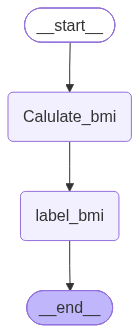

In [19]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())